In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [26]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_groq import ChatGroq
from typing import List
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field


In [27]:
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [28]:
## Document Load

loader=PyPDFLoader("../data/GenAI_Course_Content.pdf")
docs= loader.load()


## Split - Chunks

splitter=RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
docs=splitter.split_documents(docs)

## Embedding - Vectorstore


embed=GoogleGenerativeAIEmbeddings(model="gemini-embedding-2")

vectore_store=InMemoryVectorStore.from_documents(documents=docs,embedding=embed)

In [29]:
class RagState(BaseModel):
    question:str = Field(description="User Question")
    documents: List = Field(default_factory=list)
    context: str =Field(description="Context Data for user question",default="")
    answer:str=Field(description="Answer to user question",default="")


In [30]:
# question->retrieve -> context -> generate -> end


def retrieve_node(state:RagState) -> RagState:
    docs=vectore_store.similarity_search(query=state.question)
    state.documents=docs
    return state


def create_context_node(state:RagState) -> RagState:
    context=""
    
    for docs in state.documents:
        context+=docs.page_content+"\n\n"
    state.context=context
    return state

def generate_node(state:RagState) -> RagState:
    prompt=f"""You are assistant and provide the answer for user question based on the provided context,If you don't find the relevant answer ,then just say 'I don't know.'.
    Question:{state.question}
    Context:{state.context}
    """
    response=llm.invoke(prompt)
    state.answer=response.content
    return state

In [31]:
graph=StateGraph(RagState)

graph.add_node("retrieve_node",retrieve_node)
graph.add_node("create_context_node",create_context_node)
graph.add_node("generate_node",generate_node)

graph.add_edge(START,"retrieve_node")
graph.add_edge("retrieve_node", "create_context_node")
graph.add_edge("create_context_node", "generate_node")
graph.add_edge("generate_node", END)

graph=graph.compile()


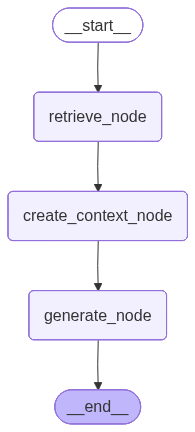

In [32]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())



In [33]:
res= graph.invoke({"question":"How many projects i will build in this course"})

In [37]:
print(res["answer"])

You will build 10+ real-world projects in this course.
